# 0. Подключение библиотек

In [16]:
import zipfile
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
import glob
import torch
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
import librosa

from collections import Counter
from torch import nn
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

# 1. Подготовка данных

In [ ]:
zipROOT = "/content/archive.zip"
resultFolder = "/content/datasetAudio"

with zipfile.ZipFile(zipROOT, "r") as z:
    z.extractall(resultFolder)

In [ ]:
!ls /content/datasetAudio

Actor_01  Actor_06  Actor_11  Actor_16	Actor_21
Actor_02  Actor_07  Actor_12  Actor_17	Actor_22
Actor_03  Actor_08  Actor_13  Actor_18	Actor_23
Actor_04  Actor_09  Actor_14  Actor_19	Actor_24
Actor_05  Actor_10  Actor_15  Actor_20	audio_speech_actors_01-24


In [ ]:
root = "/content/datasetAudio"
sampleRate = 16000
MFCC_nValue = 40
lengthFrame = 200
batchValue = 32
dataLoaderStreams = 0
hidSize = 128
layers = 1
dropout = 0.3
epochValue = 15
seedValue = 42

In [ ]:
emotionsDict = {"01": "neutral","03": "happy","05": "angry",}
audioPaths = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
print(len(audioPaths))
pathsList = []
labelsList = []
for p in audioPaths:
    name = os.path.basename(p)
    parts = name.split('.')[0].split('-')
    if len(parts) < 3:
        continue
    codeEmotion = parts[2]
    if codeEmotion not in emotionsDict:
        continue
    emotionValue= emotionsDict[codeEmotion]
    pathsList.append(p)
    labelsList.append(emotionValue)

print(len(pathsList))
print(Counter(labelsList))

2880
960
Counter({'happy': 384, 'angry': 384, 'neutral': 192})


In [ ]:
uniqueEmotionsList = []
for emotionName in labelsList:
    if emotionName not in uniqueEmotionsList:
        uniqueEmotionsList.append(emotionName)
uniqueEmotionsList.sort()
print(uniqueEmotionsList)

emotionNameToNumber ={}
numberToEmotionName = {}
currentNumber = 0
for emotionName in uniqueEmotionsList:
    emotionNameToNumber[emotionName]= currentNumber
    numberToEmotionName[currentNumber] = emotionName
    currentNumber += 1
print(emotionNameToNumber)
print(numberToEmotionName)

labelsNumberValue= []
for emotionName in labelsList:
    numVal = emotionNameToNumber[emotionName]
    labelsNumberValue.append(numVal)
print(labelsNumberValue[:20])

pathsArray = np.array(pathsList)
labelsArray = np.array(labelsNumberValue)

['angry', 'happy', 'neutral']
{'angry': 0, 'happy': 1, 'neutral': 2}
{0: 'angry', 1: 'happy', 2: 'neutral'}
[1, 1, 0, 0, 1, 2, 0, 1, 2, 1, 1, 0, 1, 0, 1, 2, 2, 0, 0, 0]


In [ ]:
trainDataAudioPath, testDataAudioPath, trainDataEmotionID, testDataEmotionID = train_test_split(pathsArray,labelsArray,
                                                                                                test_size = 0.20,
                                                                                                stratify = labelsArray,
                                                                                                random_state = seedValue)
print("Train")
print(len(trainDataAudioPath))
print("Test")
print(len(testDataAudioPath))
trainDataAudioPath = trainDataAudioPath.tolist()
testDataAudioPath  = testDataAudioPath.tolist()
trainDataEmotionID = trainDataEmotionID.tolist()
testDataEmotionID  = testDataEmotionID.tolist()

Train
768
Test
192


# 2. Предобработка аудио MFCC

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, sampleIndexVal):
        audioPath = self.paths[sampleIndexVal]
        audioSignal = librosa.load(audioPath, sr=sampleRate)[0]
        mfcc = librosa.feature.mfcc(y = audioSignal,sr = sampleRate,
                                    n_mfcc = MFCC_nValue).T
        mfcc = (mfcc - mfcc.mean(axis=0, keepdims=True)) / (mfcc.std(axis=0, keepdims=True) + 1e-8)
        if mfcc.shape[0] < lengthFrame:
            padSize = lengthFrame - mfcc.shape[0]
            mfcc = np.concatenate([mfcc, np.zeros((padSize, MFCC_nValue))], axis=0)
        else:
            mfcc = mfcc[:lengthFrame]
        return torch.tensor(mfcc, dtype=torch.float32), torch.tensor(self.labels[sampleIndexVal])

In [ ]:
trainDatasetAudio = AudioDataset(trainDataAudioPath, trainDataEmotionID)
testDatasetAudio  = AudioDataset(testDataAudioPath,  testDataEmotionID)
trainDataLoaderAudio = DataLoader(trainDatasetAudio,batch_size = batchValue,shuffle = True,num_workers = dataLoaderStreams)

for batchMFCC, batchLabels in trainDataLoaderAudio:
    print(batchMFCC.shape, batchLabels.shape)
    break
print(batchMFCC.shape)
print(batchLabels.shape)
print(batchLabels[:10])

torch.Size([32, 200, 40]) torch.Size([32])
torch.Size([32, 200, 40])
torch.Size([32])
tensor([1, 0, 2, 0, 0, 1, 1, 0, 1, 0])


# 3. Модель LSTM

In [ ]:
%load_ext tensorboard

In [ ]:
numEmotionList = len(set(labelsArray))

class emotionAudioLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        if layers > 1:
            dropoutVal = dropout
        else:
            dropoutVal = 0
        self.lstm = nn.LSTM(input_size=MFCC_nValue,hidden_size=hidSize,
                            num_layers=layers,batch_first=True,
                            dropout=dropoutVal,bidirectional=True)
        self.midLayer = nn.Linear(hidSize * 2, hidSize)
        self.dropoutMid = nn.Dropout(dropout)


        self.outputLayer = nn.Linear(hidSize, numEmotionList)

    def forward(self, batchMFCCVal):
        timeStepOutput, (h, c) = self.lstm(batchMFCCVal)
        lastHid = torch.cat([h[-2], h[-1]], dim=1)
        x = self.midLayer(lastHid)
        x = F.relu(x)
        x = self.dropoutMid(x)
        pred = self.outputLayer(x)
        return pred, lastHid

testDataLoaderAudio = DataLoader(testDatasetAudio,
                                 batch_size=batchValue,
                                 shuffle=False,
                                 num_workers=dataLoaderStreams)
trainCounts = Counter(trainDataEmotionID)
totalTrain = len(trainDataEmotionID)
classWeights = []
for classID in range(numEmotionList):
    c = trainCounts[classID]
    w = totalTrain / c
    classWeights.append(w)
classWeightsTensor = torch.tensor(classWeights, dtype=torch.float32)

epoch = epochValue

learningRate = 3e-3
model = emotionAudioLSTM()
lossFunc = nn.CrossEntropyLoss(weight=classWeightsTensor)
opt = torch.optim.Adam(model.parameters(), lr=learningRate)
writer = SummaryWriter(log_dir="tns_board/audioEmotionLSTM")

for oneEpoch in range(epoch):
    model.train()

    sumLossTrain = 0
    batchTrain = 0
    for batchMFCC, batchY in trainDataLoaderAudio:
        opt.zero_grad()
        pred, lastHid = model(batchMFCC)
        loss = lossFunc(pred, batchY)
        loss.backward()
        opt.step()
        sumLossTrain+= loss.item()
        batchTrain += 1
    avgTrainLoss= sumLossTrain / batchTrain

    model.eval()
    countLastValue = 0
    countAllValue  = 0
    sumLossTest = 0
    batchTest = 0
    for batchMFCC, batchY in testDataLoaderAudio:
        pred, lastHid = model(batchMFCC)
        lossTest = lossFunc(pred, batchY)
        sumLossTest +=lossTest.item()
        batchTest+= 1
        predLabels = pred.argmax(dim=1)
        countLastValue+= (predLabels == batchY).sum().item()
        countAllValue  += batchY.size(0)
    testAcc= countLastValue / countAllValue
    avgTestLoss = sumLossTest / batchTest
    writer.add_scalar("loss-train", avgTrainLoss, oneEpoch)
    writer.add_scalar("loss-test", avgTestLoss, oneEpoch)
    writer.add_scalar("acc-test", testAcc, oneEpoch)
    print(oneEpoch + 1, "-", epoch, "trainLoss:", round(avgTrainLoss, 4),
          "testLoss:", round(avgTestLoss, 4), "testAcc:", round(testAcc, 4))

    model.eval()
    trainCorrect = 0
    trainTotal = 0
    for batchMFCC, batchY in trainDataLoaderAudio:
        pred, lastHid = model(batchMFCC)
        labels = pred.argmax(dim=1)
        trainCorrect+= (labels == batchY).sum().item()
        trainTotal+= batchY.size(0)
    resTrainAcc = trainCorrect / trainTotal
    print("final trainAcc:")
    print(resTrainAcc)

    testCorrect = 0
    testTotal = 0
    for batchMFCC, batchY in testDataLoaderAudio:
        pred, lastHid = model(batchMFCC)
        labels =pred.argmax(dim=1)
        testCorrect += (labels == batchY).sum().item()
        testTotal+= batchY.size(0)
    resTestAcc = testCorrect / testTotal
    print("final testAcc:")
    print(resTestAcc)
writer.close()

1 - 15 trainLoss: 1.0132 testLoss: 1.0151 testAcc: 0.4427
final trainAcc:
0.4934895833333333
final testAcc:
0.4427083333333333
2 - 15 trainLoss: 0.8983 testLoss: 0.871 testAcc: 0.4792
final trainAcc:
0.5130208333333334
final testAcc:
0.4791666666666667
3 - 15 trainLoss: 0.8166 testLoss: 0.7963 testAcc: 0.5677
final trainAcc:
0.5924479166666666
final testAcc:
0.5677083333333334
4 - 15 trainLoss: 0.7619 testLoss: 0.8403 testAcc: 0.4635
final trainAcc:
0.5065104166666666
final testAcc:
0.4635416666666667
5 - 15 trainLoss: 0.7728 testLoss: 0.7506 testAcc: 0.6562
final trainAcc:
0.6979166666666666
final testAcc:
0.65625
6 - 15 trainLoss: 0.7024 testLoss: 0.7314 testAcc: 0.6354
final trainAcc:
0.6770833333333334
final testAcc:
0.6354166666666666
7 - 15 trainLoss: 0.6502 testLoss: 0.6562 testAcc: 0.6927
final trainAcc:
0.7200520833333334
final testAcc:
0.6927083333333334
8 - 15 trainLoss: 0.6066 testLoss: 0.701 testAcc: 0.6771
final trainAcc:
0.7135416666666666
final testAcc:
0.67708333333333

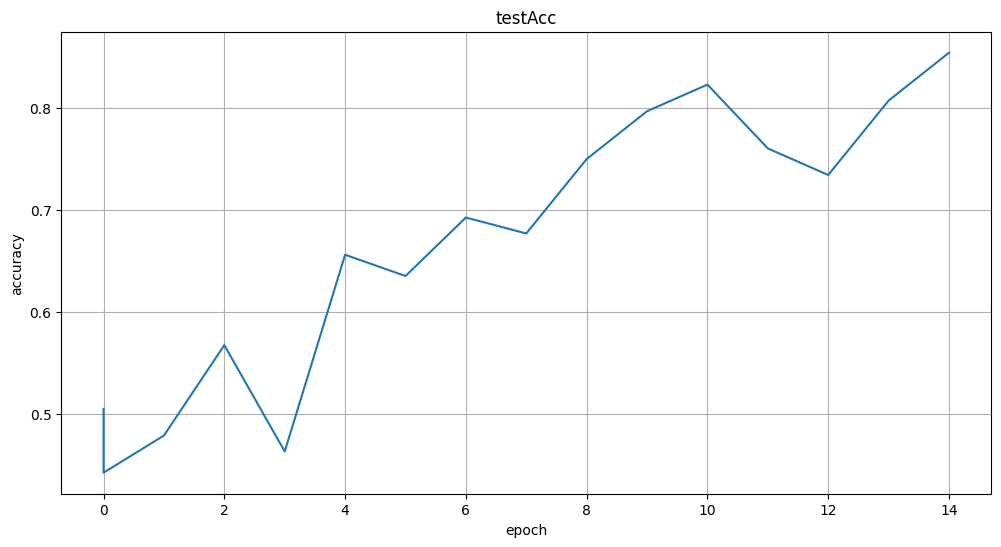

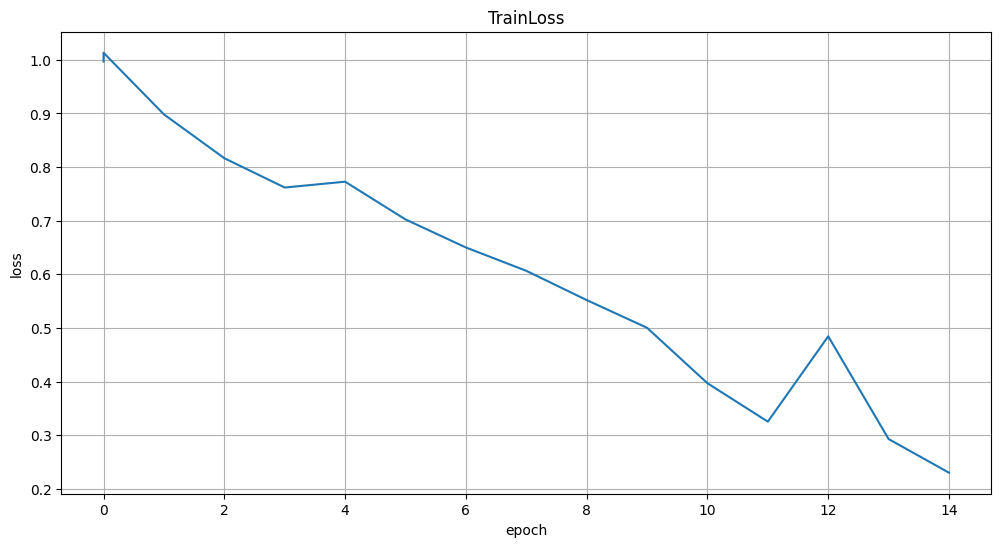

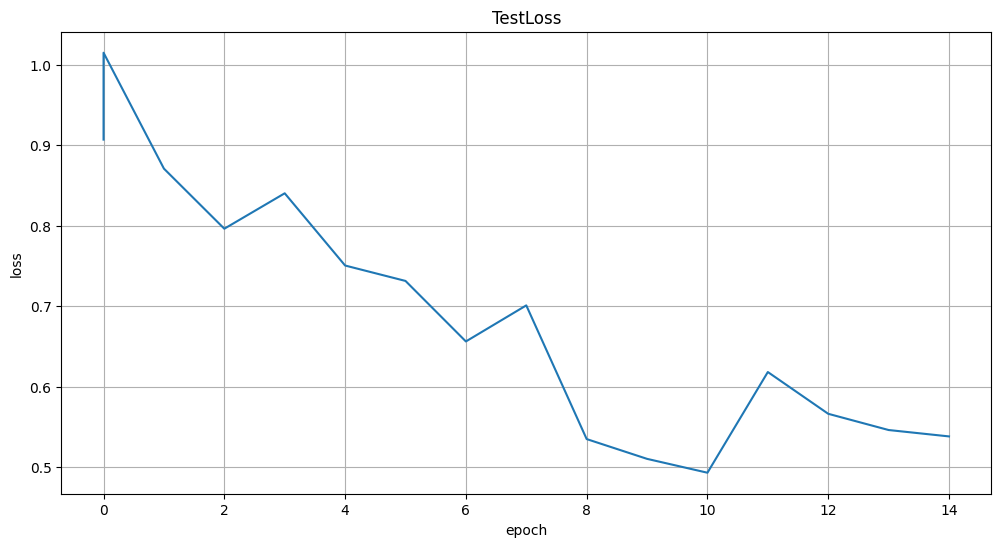

In [17]:
LOGS = "tns_board/audioEmotionLSTM"
allFiles = glob.glob(os.path.join(LOGS, "*tfevents*"))
eventAccRes = event_accumulator.EventAccumulator(LOGS)
eventAccRes.Reload()
accuracyBoard = eventAccRes.Scalars("acc-test")
numberAccBoard = [x.step for x in accuracyBoard]
valuesAccBoard = [x.value for x in accuracyBoard]
plt.figure(figsize=(12,6))
plt.plot(numberAccBoard, valuesAccBoard)
plt.title("testAcc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(True)
plt.savefig("testAcc.png")
plt.show()

lossTrainBoard = eventAccRes.Scalars("loss-train")
numberTrainBoard = [x.step for x in lossTrainBoard]
valueTrainBoard = [x.value for x in lossTrainBoard]
plt.figure(figsize=(12,6))
plt.plot(numberTrainBoard, valueTrainBoard)
plt.title("TrainLoss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.savefig("trainLoss.png")
plt.show()

lossTestBoard = eventAccRes.Scalars("loss-test")
numberTestBoard = [x.step for x in lossTestBoard]
valueTestBoard = [x.value for x in lossTestBoard]
plt.figure(figsize=(12,6))
plt.plot(numberTestBoard, valueTestBoard)
plt.title("TestLoss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.savefig("testLoss.png")
plt.show()

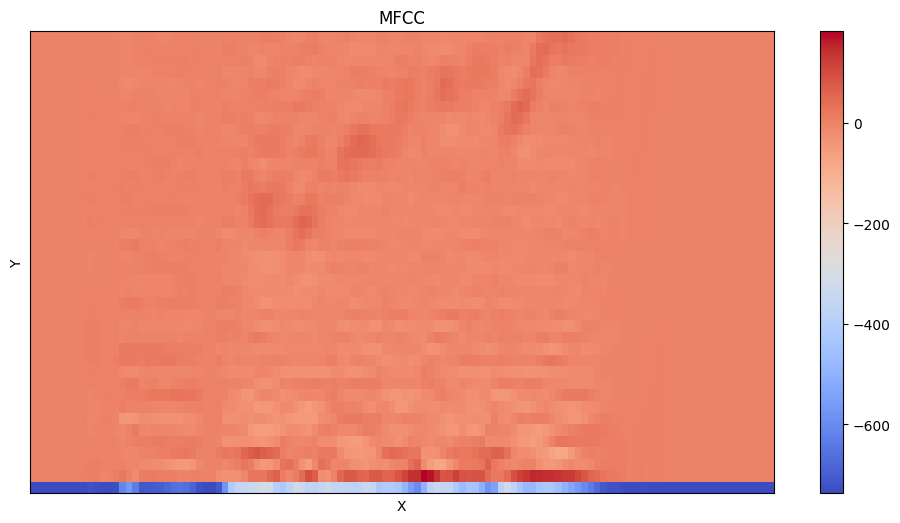

In [18]:
y, sr = librosa.load(trainDataAudioPath[0], sr=sampleRate)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
plt.figure(figsize=(12, 6))
librosa.display.specshow(mfcc, sr=sr)
plt.colorbar()
plt.title("MFCC")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 4. t-SNE

In [19]:
allPaths = trainDataAudioPath + testDataAudioPath
allLabels = trainDataEmotionID + testDataEmotionID
fullDatasetAudio = AudioDataset(allPaths, allLabels)
fullDataLoaderAudio = DataLoader(fullDatasetAudio,batch_size=batchValue,shuffle=False,num_workers=dataLoaderStreams)
embList = []
labelList = []
model.eval()
for batchMFCC, batchY in fullDataLoaderAudio:
    pred, lastHid = model(batchMFCC)
    embList.append(lastHid.detach().cpu().numpy())
    labelList.append(batchY.detach().cpu().numpy())

embArray = np.concatenate(embList, axis=0)
labelArray = np.concatenate(labelList, axis=0)
print("embArray:")
print(embArray.shape)
print("labelArray:")
print(labelArray.shape)

embArray:
(960, 256)
labelArray:
(960,)


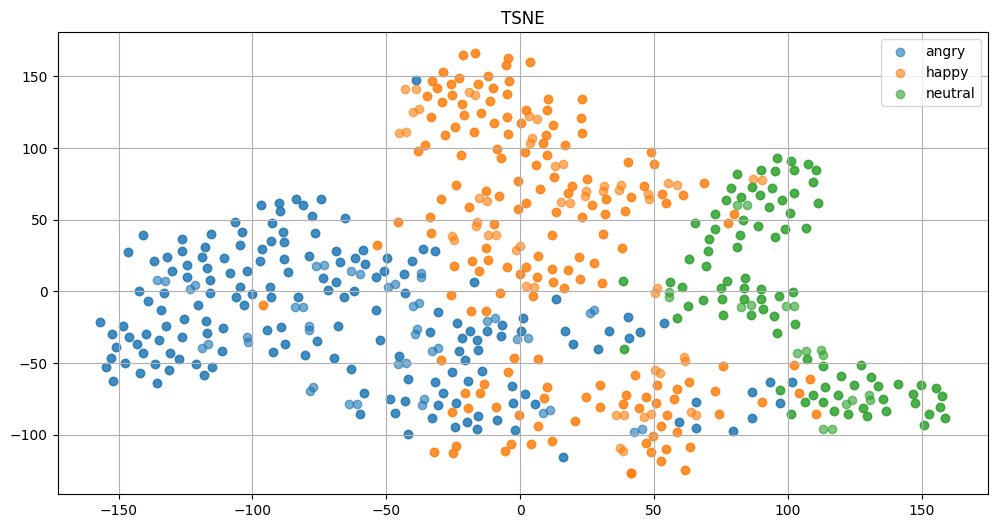

In [20]:
modelTSNE = TSNE(n_components=2, random_state=seedValue)
embVal = modelTSNE.fit_transform(embArray)
plt.figure(figsize=(12,6))
for i in range(numEmotionList):
    j = labelArray == i
    plt.scatter(embVal[j, 0],embVal[j, 1],alpha=0.6,label=numberToEmotionName[i])
plt.legend()
plt.title("TSNE")
plt.grid(True)
plt.show()